This notebook uses strong- and weak-constraint 4D-Var method to assimilate the KS system:

$u_{t} + u_{xx} + u_{xxxx} + \dfrac{1}{2}(u^2)_x$ = 0

In [1]:
import os
import torch
from matplotlib import pyplot as plt
from time import time
from tensordict import TensorDict
from NLADV.advect_solver import NonlinAdv1D
from NLADV.time_stepping import ETDRK2
os.chdir('..')
from adda.variational.strong_constraint_4dvar import sc4dvar_single_window
from adda.variational.weak_constraint_4dvar import wc4dvar_single_window
from adda.system.state import State
from adda.util.visualization import show_1dseqimg
from adda.observation.operators import random_sparse_noisy_obs
from adda.util.initialization import naive_initialization
from adda.probability.distributions import DiagonalGaussian

## Generation of groundtruth data

In [2]:
torch.backends.cudnn.deterministic = True
torch.manual_seed(42)
# Experiment parameters
domain_size = 100.0
num_spat = 200
dt = 0.1
# These are the coefficients for the linear terms of the KS equation.
coeffs = [0, 0, -1.0, 0, -1.0]
# Exponential Time Differencing Runge-Kutta 2nd order (ETDRK2).
integrator = ETDRK2
tot_timesteps = 1600
# Create the solver object, which will be used as the forward operator in the 4D-Var optimization and data generation.
forward_operator = NonlinAdv1D(domain_size=domain_size, num_spat=num_spat, dt=dt, linear_coeffs=coeffs, advect_coeff=1.0, integrator=integrator)

In [3]:
mesh = torch.linspace(0.0, domain_size, num_spat+1)[:-1]
# Sine with 16 periods over the domain as the initial condition.
initial_state = torch.sin(16 * torch.pi * mesh / domain_size)
initial_state = initial_state.unsqueeze(0) # add batch and time dimensions
forecast_steps = torch.arange(0, tot_timesteps * dt, dt)
# Generated ground truth data by integrating the initial state forward in time.
ks_series = forward_operator.integrate(time=forecast_steps, state=initial_state).squeeze()

torch.Size([800, 200])


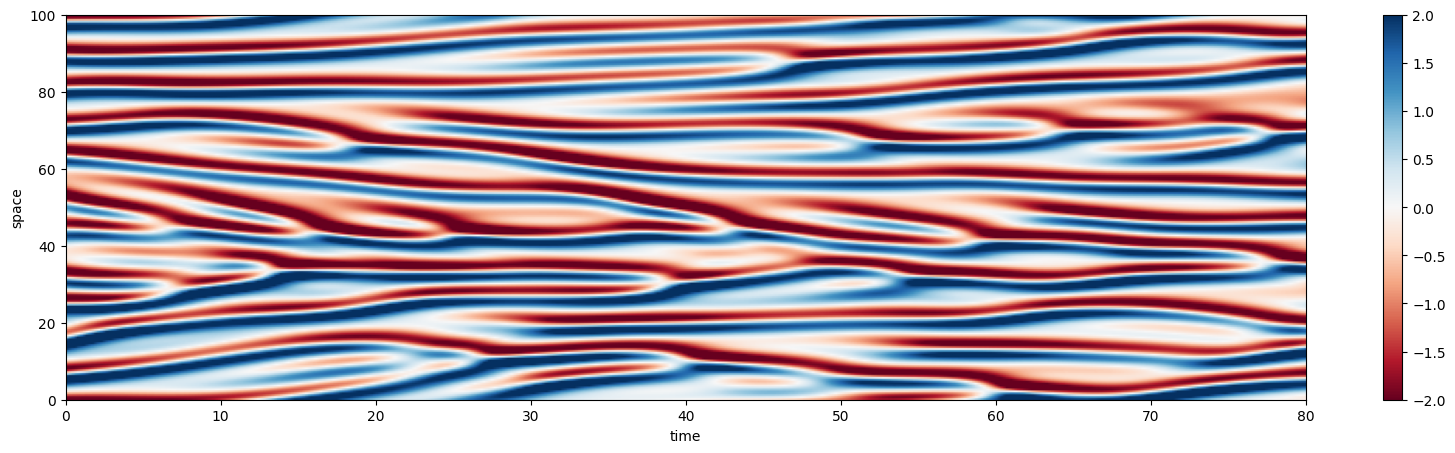

In [4]:
# Cutoff applied to the beginning of the series to remove the initial transient stage.
cutoff = 800

ctrj = ks_series[cutoff:, :].numpy()
plt.figure(figsize=(20, 5))
plt.imshow(
    ctrj.transpose(),
    cmap="RdBu",
    aspect="auto",
    origin="lower",
    extent=(0, ctrj.shape[0] * dt, 0, domain_size),
    vmin=-2,
    vmax=2,
)
plt.colorbar()
plt.xlabel("time")
plt.ylabel("space")
print(ks_series[cutoff:, :].shape)

In [5]:
true_series = ks_series[cutoff:]
true_initial_state = true_series[0]
forecast_steps = torch.arange(0, (tot_timesteps - cutoff) * dt, dt)
true_series = State(true_series.reshape(1, -1, num_spat), time_axis=forecast_steps)

Text(0.5, 1.0, 'Initial Ground Truth State of the KS System')

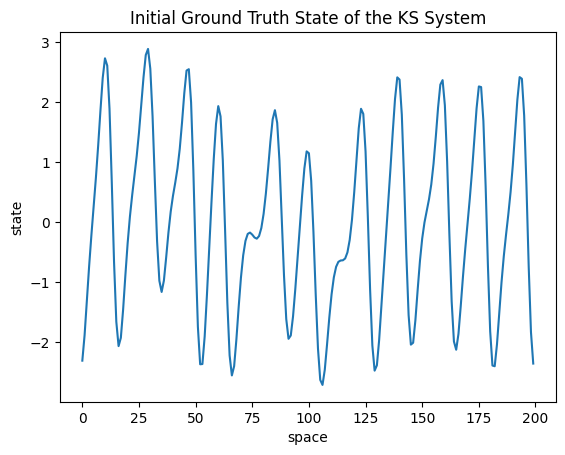

In [6]:
plt.plot(true_initial_state)
plt.xlabel("space")
plt.ylabel("state")
plt.title("Initial Ground Truth State of the KS System")

# Generation of Sparse and Noisy Observations

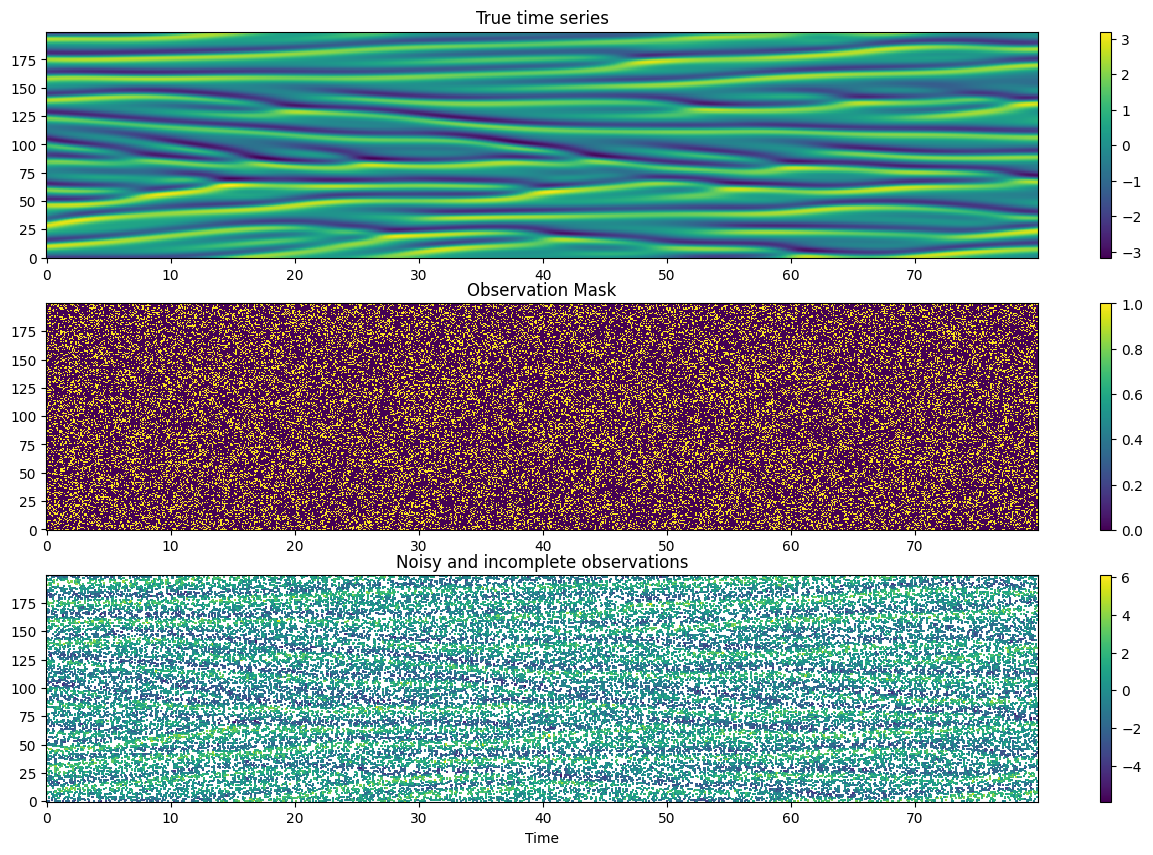

In [7]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.25 # 75% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_series, noise_amplitude, p_obs)

valid_obs = observations.state.fields['x'][0].T
valid_obs[torch.logical_not(observations.mask.fields['x'][0].T)] = torch.nan
fig, ax = plt.subplots(3, 1, figsize=(16,10))

show_1dseqimg(true_series.fields['x'][0].T, dt=dt, ax=ax[0], title="True time series")
show_1dseqimg(observations.mask.fields['x'][0].T, dt=dt, ax=ax[1], title="Observation Mask")
show_1dseqimg(valid_obs, dt=dt, ax=ax[2], title="Noisy and incomplete observations", x_label="Time")

In [8]:
# In order to use the 4D-Var/EnKF function, you should always have a function like this taking the state, dt, dynamic_inputs and static_inputs
def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    B, T = x.fields.batch_size[:2]
    input = x.fields["x"].reshape(B * T, num_spat)
    integrated = forward_operator.integrate(torch.arange(2) * dt, input)[:, -2:-1] # integrate over a time step, take the current time
    integrated = integrated.reshape(B, T, num_spat)
    new_fields = TensorDict(x=integrated, batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + dt)  # return State object, advancing time

# Strong-constraint 4D-var

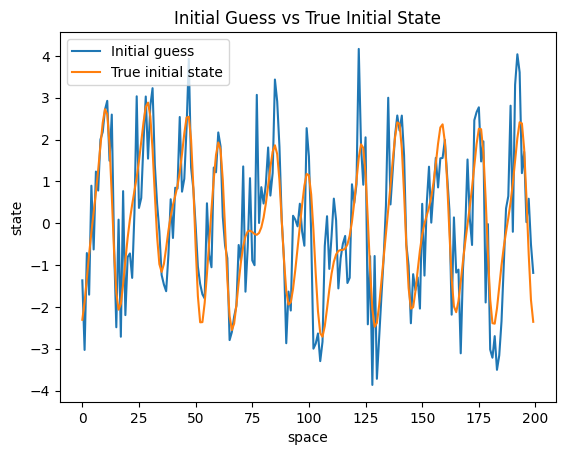

In [9]:
initialization = naive_initialization(observations)  # state estimate for all time points
initialization = initialization[:, :1]  # first time point only

plt.plot(initialization.fields['x'].squeeze(), label='Initial guess')
plt.plot(true_series.fields['x'].squeeze()[0], label='True initial state')
plt.legend()
plt.title("Initial Guess vs True Initial State")
plt.xlabel("space")
plt.ylabel("state")
plt.show()

In [10]:
n_obs_steps = 100 # we assimilate only on the earliest time steps, otherwise the optimization would be too unstable
time_window = (observations.state.time_axis[0], observations.state.time_axis[n_obs_steps])

obs_op_opt = obs_op.restrict_time_domain(*time_window)
observations_opt = observations.restrict_time_domain(*time_window)

In [11]:
t0 = time()
# We are using Adam optimizer with CyclicLR scheduler
assimilated_ic = sc4dvar_single_window(next_step_function, 
                                       observations_opt, 
                                       obs_op_opt, 
                                       initialization,                                        
                                        optimizer_class=torch.optim.Adam,
                                        optimizer_pars={'lr': 2e-2},
                                        scheduler_class=torch.optim.lr_scheduler.CyclicLR,
                                        scheduler_pars={'base_lr': 2e-2, 'max_lr': 5e-2, 'step_size_up': 10},
                                        n_steps=100,
                                        verbose=1,)                                     
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

iteration 0: loss = 12875.3232421875
iteration 0: lr = 0.023000000000000003
iteration 1: loss = 12294.69140625
iteration 1: lr = 0.026000000000000006
iteration 2: loss = 11650.27734375
iteration 2: lr = 0.028999999999999998
iteration 3: loss = 10936.0400390625
iteration 3: lr = 0.032
iteration 4: loss = 10168.859375
iteration 4: lr = 0.035
iteration 5: loss = 9371.91796875
iteration 5: lr = 0.038000000000000006
iteration 6: loss = 8573.705078125
iteration 6: lr = 0.04100000000000001
iteration 7: loss = 7810.7041015625
iteration 7: lr = 0.044
iteration 8: loss = 7112.83984375
iteration 8: lr = 0.047
iteration 9: loss = 6575.55712890625
iteration 9: lr = 0.05
iteration 10: loss = 6341.345703125
iteration 10: lr = 0.047
iteration 11: loss = 5987.79443359375
iteration 11: lr = 0.044
iteration 12: loss = 5848.18212890625
iteration 12: lr = 0.04100000000000001
iteration 13: loss = 5855.779296875
iteration 13: lr = 0.038000000000000006
iteration 14: loss = 5787.203125
iteration 14: lr = 0.035

In [12]:
assim_input = assimilated_ic.fields['x'].reshape(1, num_spat)
initialization_input = initialization.fields['x'].reshape(1, num_spat)
assimilated_trajectory = forward_operator.integrate(time=forecast_steps, state=assim_input).squeeze()
trajectories_from_initial_guess = forward_operator.integrate(time=forecast_steps, state=initialization_input).squeeze()

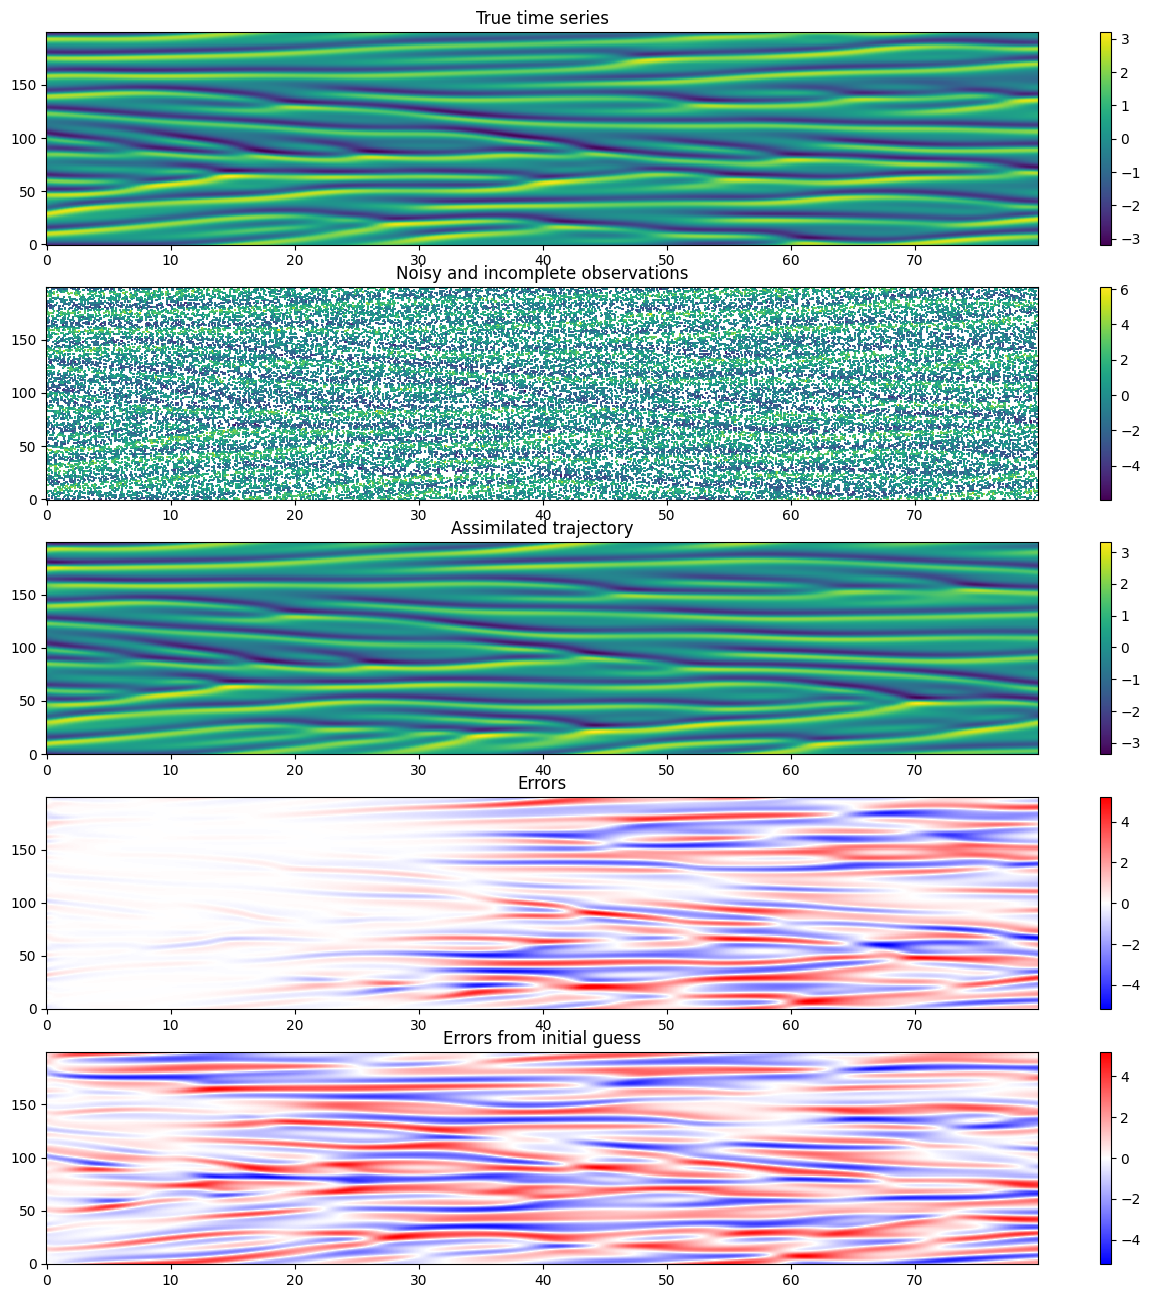

In [13]:
error = assimilated_trajectory.detach() - true_series.fields['x']
error_2 = trajectories_from_initial_guess.detach() - true_series.fields['x']
fig, ax = plt.subplots(5, 1, figsize=(16,16))
show_1dseqimg(true_series.fields['x'][0].T, dt=dt, ax=ax[0], title="True time series")
show_1dseqimg(valid_obs, dt=dt, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg(assimilated_trajectory.detach().T, dt=dt, ax=ax[2], title="Assimilated trajectory")
show_1dseqimg(error.detach().squeeze().T, dt=dt, ax=ax[3], title="Errors", cmap="bwr", vmin=-torch.max(torch.abs(error_2)), vmax=torch.max(torch.abs(error_2)))
show_1dseqimg(error_2.detach().squeeze().T, dt=dt, ax=ax[4], title="Errors from initial guess", cmap="bwr", vmin=-torch.max(torch.abs(error_2)),  vmax=torch.max(torch.abs(error_2)))

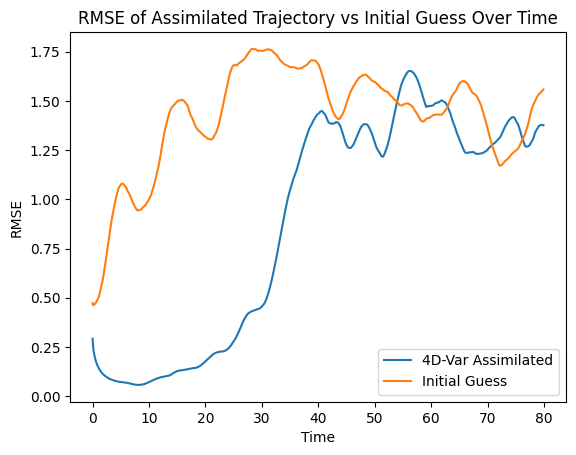

In [14]:
RMSE_over_time_assimilated = torch.mean(torch.sqrt((error.squeeze().T ** 2)), dim=0)
RMSE_over_time_initial = torch.mean(torch.sqrt((error_2.squeeze().T ** 2)), dim=0)

fig, ax = plt.subplots()
plt.plot(forecast_steps, RMSE_over_time_assimilated.squeeze(), label='4D-Var Assimilated')
plt.plot(forecast_steps, RMSE_over_time_initial.squeeze(), label='Initial Guess')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE')
plt.title("RMSE of Assimilated Trajectory vs Initial Guess Over Time")
plt.legend()

# Weak-constraint 4D-var

In [15]:
n_steps = true_series.time_axis.nelement()
print(n_steps)
# We define a diagonal Gaussian with mean 0 and standard deviation 1 for the model error distribution, this will be used in the weak-constraint 4D-Var optimization to allow for model errors.
model_error_distribs = DiagonalGaussian(TensorDict({'x': torch.zeros(1, n_steps - 1, num_spat)}), 
                                        TensorDict({'x': torch.ones(1, n_steps - 1, num_spat)}))

800


In [16]:
initialization = naive_initialization(observations)  # state estimate for all time points

In [17]:
# This should take around a minute to run on a reasonably powerful CPU
t0 = time()
assimilated_states = wc4dvar_single_window(next_step_function, 
                                          observations, 
                                          obs_op, 
                                          model_error_distribs,
                                          x_init=initialization, 
                                          optimizer_pars={'lr': 1},
                                          alpha=1e4,
                                          n_steps=50,
                                          verbose=0)                                       
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

assimilated_states = assimilated_states.detach()

Total time for the 4D-Var optimization: 39.31878304481506 seconds


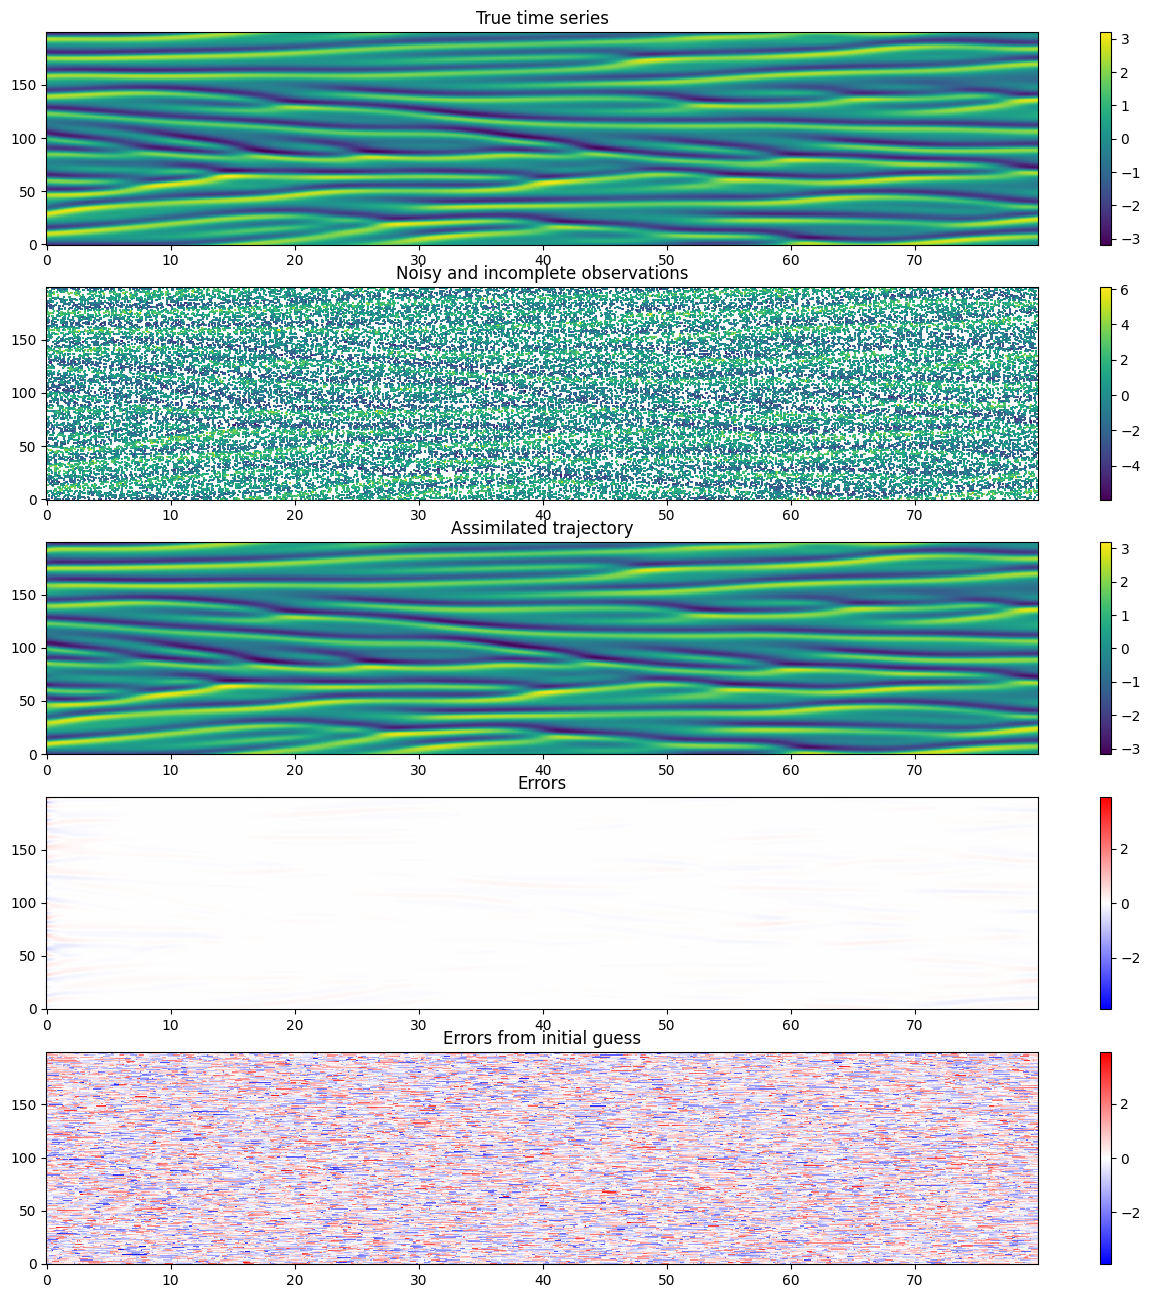

In [18]:
error = assimilated_states.fields['x'].detach() - true_series.fields['x']
error_2 = initialization.fields['x'].detach() - true_series.fields['x']
fig, ax = plt.subplots(5, 1, figsize=(16,16))
show_1dseqimg(true_series.fields['x'][0].T, dt=dt, ax=ax[0], title="True time series", vmin=torch.min(true_series.fields['x']), vmax=torch.max(true_series.fields['x']))
show_1dseqimg(valid_obs, dt=dt, ax=ax[1], title="Noisy and incomplete observations")
show_1dseqimg(assimilated_states.fields['x'].detach().squeeze().T, dt=dt, ax=ax[2], vmin=torch.min(true_series.fields['x']), vmax=torch.max(true_series.fields['x']), title="Assimilated trajectory")
show_1dseqimg(error.detach().squeeze().T, dt=dt, ax=ax[3], title="Errors", cmap="bwr", vmin=-torch.max(torch.abs(error_2)), vmax=torch.max(torch.abs(error_2)))
show_1dseqimg(error_2.detach().squeeze().T, dt=dt, ax=ax[4], title="Errors from initial guess", cmap="bwr", vmin=-torch.max(torch.abs(error_2)),  vmax=torch.max(torch.abs(error_2)))

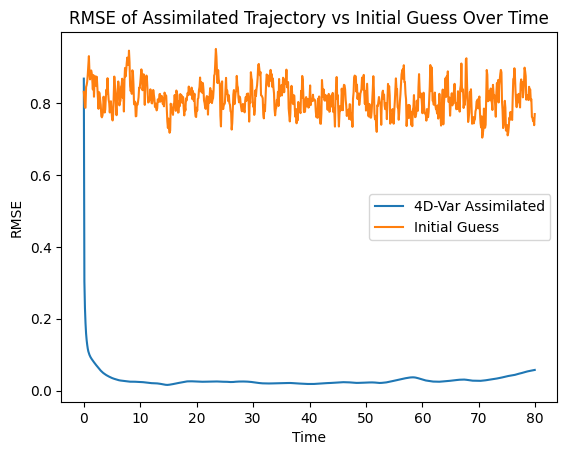

In [19]:
RMSE_over_time_assimilated = torch.mean(torch.sqrt((error.squeeze().T ** 2)), dim=0)
RMSE_over_time_initial = torch.mean(torch.sqrt((error_2.squeeze().T ** 2)), dim=0)

fig, ax = plt.subplots()
plt.plot(forecast_steps, RMSE_over_time_assimilated.squeeze(), label='4D-Var Assimilated')
plt.plot(forecast_steps, RMSE_over_time_initial.squeeze(), label='Initial Guess')
ax.set_xlabel('Time')
ax.set_ylabel('RMSE')
plt.title("RMSE of Assimilated Trajectory vs Initial Guess Over Time")
plt.legend()
plt.show()